# Debug Trading Environment Episode

Run an episode and visualize actions, rewards, positions, and portfolio value.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from rl_trading_lab.environment.trading_env import TradingEnv
from rl_trading_lab.utils.data_processor import DataProcessor
from rl_trading_lab.utils import CheckpointManager
from rl_trading_lab.config import load_config
from omegaconf import OmegaConf
from hydra import compose, initialize_config_dir

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Imports successful!")

Imports successful!


In [2]:
import os; os.chdir("..")

In [3]:
print(os.getcwd())

/Users/mohamedali/trading_project/rl-trading-lab


## Load Configuration and Data

In [4]:
# Load config using Hydra
config_dir = Path('configs').resolve()

with initialize_config_dir(config_dir=str(config_dir), version_base=None):
    cfg = compose(config_name='config', overrides=[])
    config = load_config(cfg)

print(f"Reward type: {config.env.environment_params.reward_type}")
print(f"Initial balance: ${config.env.environment_params.initial_balance:,.2f}")
print(f"Commission rate: {config.env.environment_params.commission_rate}")
print(f"Lookback window: {config.env.environment_params.lookback_window}")
print(f"Hold closes position: {config.env.environment_params.hold_closes_position}")

Reward type: returns
Initial balance: $10,000.00
Commission rate: 0.0
Lookback window: 20
Hold closes position: True


In [5]:
# Load data using DataProcessor
data_processor = DataProcessor(
    data_path=config.data.train_data_path,
    observation_config=config.observation,
    feature_engineering_config=config.feature_engineering,
    val_split=config.data.val_split,
    test_split=config.data.test_split,
)

train_df, val_df, test_df, observation_features = data_processor.process()

print(f"Train: {len(train_df)} bars")
print(f"Val: {len(val_df)} bars")
print(f"Test: {len(test_df)} bars")
print(f"Observation features ({len(observation_features)}): {observation_features}")
print(f"\nAvailable columns in data: {list(train_df.columns)[:10]}...")

Train: 7790 bars
Val: 2225 bars
Test: 1112 bars
Observation features (4): ['ratio_sma_5_close_zscore', 'ratio_sma_20_close_zscore', 'ratio_range_close_zscore', 'fracdiff_0.4_zscore']

Available columns in data: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'ratio_sma_5_close', 'ratio_sma_20_close', 'ratio_range_close', 'fracdiff_0.4']...


## Create Environment

In [6]:
df = train_df

In [7]:
# Create test environment
env_params = config.env.environment_params

test_env = TradingEnv(
    df=df,
    lookback_window=env_params.lookback_window,
    initial_balance=env_params.initial_balance,
    commission_rate=env_params.commission_rate,
    slippage_rate=env_params.slippage_rate,
    reward_type=env_params.reward_type,
    discrete_actions=env_params.discrete_actions,
    max_position_pct=env_params.max_position_pct,
    features_to_use=observation_features,  # Use observation_features instead of feature_names
    randomize_start=False,
    min_episode_length=env_params.min_episode_length,
    hold_closes_position=env_params.hold_closes_position,
    price_column=config.env.price_column,
)

print(f"✓ Environment created")
print(f"  Observation space: {test_env.observation_space.shape}")
print(f"  Action space: {test_env.action_space}")
print(f"  Max steps: {test_env.max_steps}")
print(f"  Hold closes position: {test_env.hold_closes_position}")

✓ Environment created
  Observation space: (84,)
  Action space: Discrete(3)
  Max steps: 7789
  Hold closes position: True


## Load Trained Agent with CheckpointManager

In [8]:
# Load latest trained model using CheckpointManager
run_id = "DQN_returns_20251027_213740"
checkpoint_dir = Path("checkpoints")

# Find latest training run
training_runs = [d for d in checkpoint_dir.iterdir() if d.is_dir()]
training_runs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
latest_run = training_runs[0]

print(f"📂 Loading from: {latest_run.name}\n")

# Load with CheckpointManager
manager = CheckpointManager(latest_run)
model, test_vec_env = manager.load_best_model(test_env, verbose=1)

print(f"\n✓ Model loaded successfully!")
print(f"  Policy: {type(model.policy).__name__}")
print(f"  Device: {model.device}")

📂 Loading from: DQN_returns_20251027_213740


✓ Model loaded successfully!
  Policy: DQNPolicy
  Device: cpu


## Run Episode with Trained Agent

In [ ]:
def run_agent_episode(vec_env, model):
    """Run episode with trained agent"""
    obs = vec_env.reset()
    
    # Get the unwrapped environment for direct access
    unwrapped_env = vec_env.venv.envs[0]
    
    data = {
        'step': [],
        'action': [],
        'reward': [],
        'position': [],
        'balance': [],
        'portfolio_value': [],
        'price': [],
        'terminated': [],
    }
    
    done = False
    step = 0
    
    while not done:
        # Get action from agent
        action, _ = model.predict(obs, deterministic=True)
        
        # Step
        obs, reward, done, info = vec_env.step(action)
        
        # Extract from vectorized format
        if isinstance(done, np.ndarray):
            done = done[0]
        if isinstance(action, np.ndarray):
            action = action[0]
        if isinstance(reward, np.ndarray):
            reward = reward[0]
        
        # Collect data from unwrapped env
        data['step'].append(step)
        data['action'].append(action)
        data['reward'].append(reward)
        data['position'].append(unwrapped_env.position.size)
        data['balance'].append(unwrapped_env.balance)
        data['portfolio_value'].append(unwrapped_env._get_portfolio_value())
        data['price'].append(unwrapped_env._get_current_price())
        data['terminated'].append(done)
        
        step += 1
        
        if step > 500:  # Safety limit
            break
    
    return pd.DataFrame(data)

# Run episode
df_agent = run_agent_episode(test_vec_env, model)

print(f"\n{'='*60}")
print(f"Episode completed: {len(df_agent)} steps")
print(f"Final portfolio value: ${df_agent['portfolio_value'].iloc[-1]:,.2f}")
print(f"Final return: {(df_agent['portfolio_value'].iloc[-1] / env_params.initial_balance - 1) * 100:.2f}%")
print(f"Final position: {df_agent['position'].iloc[-1]:.4f}")
print(f"{'='*60}")

df_agent.head()

---

NameError: name 'df_agent' is not defined

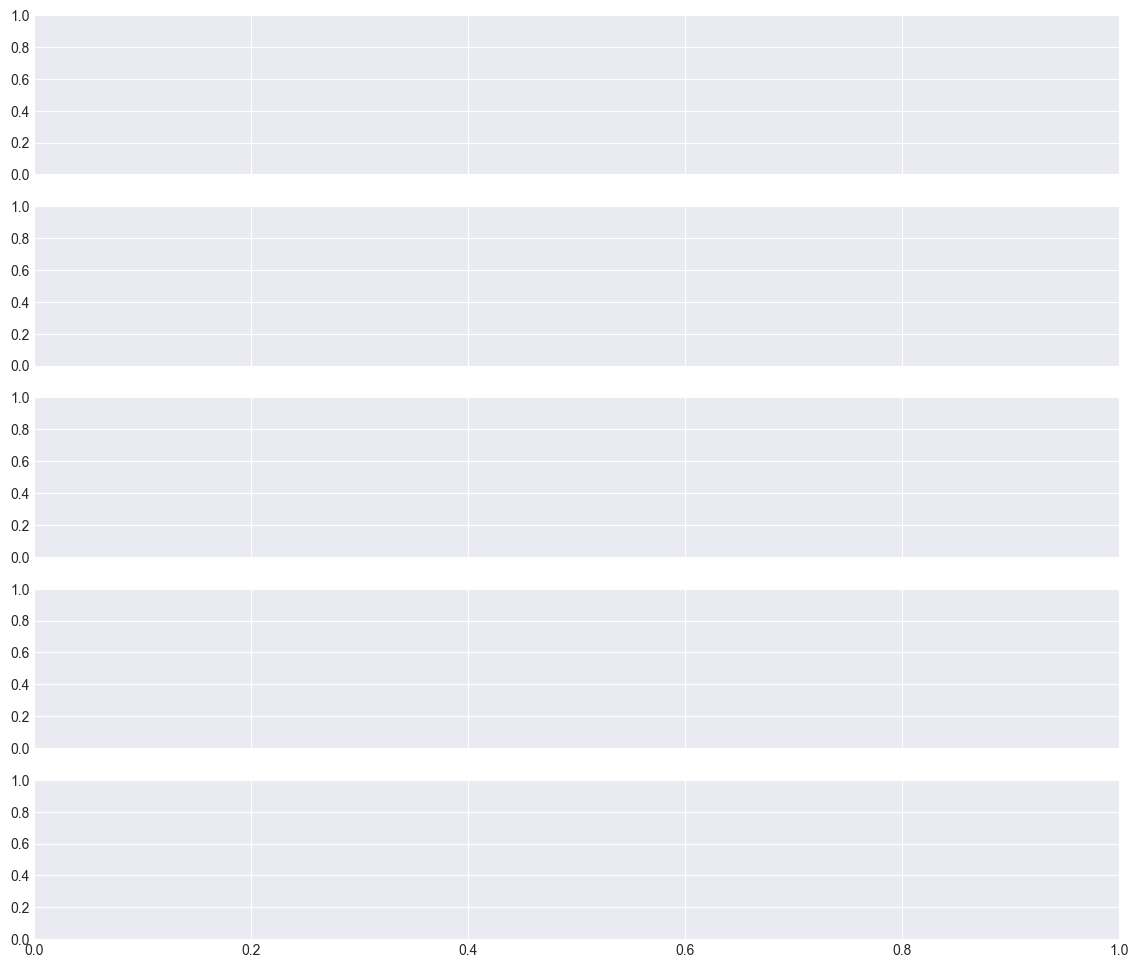

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

# 1. Portfolio Value
axes[0].plot(df_agent['step'], df_agent['portfolio_value'], label='Portfolio Value', linewidth=2)
axes[0].axhline(y=env_params.initial_balance, color='red', linestyle='--', alpha=0.5, label='Initial Balance')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].set_title('Portfolio Value Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Price
axes[1].plot(df_agent['step'], df_agent['price'], label='Price', color='orange', linewidth=1.5)
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Asset Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Actions
action_colors = {0: 'gray', 1: 'green', 2: 'red'}
action_labels = {0: 'Hold', 1: 'Buy', 2: 'Sell'}
for action_val in [0, 1, 2]:
    mask = df_agent['action'] == action_val
    axes[2].scatter(df_agent[mask]['step'], df_agent[mask]['action'], 
                   c=action_colors[action_val], label=action_labels[action_val], alpha=0.6, s=20)
axes[2].set_ylabel('Action')
axes[2].set_title('Actions Taken')
axes[2].set_yticks([0, 1, 2])
axes[2].set_yticklabels(['Hold', 'Buy', 'Sell'])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# 4. Position
axes[3].plot(df_agent['step'], df_agent['position'], label='Position Size', color='purple', linewidth=1.5)
axes[3].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[3].set_ylabel('Position Size')
axes[3].set_title('Position Size Over Time')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

# 5. Rewards
axes[4].plot(df_agent['step'], df_agent['reward'], label='Reward', color='blue', alpha=0.7, linewidth=1)
axes[4].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[4].set_ylabel('Reward')
axes[4].set_xlabel('Step')
axes[4].set_title('Rewards')
axes[4].legend()
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis: Check for Issues

In [ ]:
print("=" * 60)
print("EPISODE SUMMARY")
print("=" * 60)
print(f"Total steps: {len(df_agent)}")
print(f"Initial balance: ${env_params.initial_balance:,.2f}")
print(f"Final portfolio value: ${df_agent['portfolio_value'].iloc[-1]:,.2f}")
print(f"Final return: {(df_agent['portfolio_value'].iloc[-1] / env_params.initial_balance - 1) * 100:.2f}%")
print()

print("Action Distribution:")
print(df_agent['action'].value_counts().sort_index())
print()

print("Reward Statistics:")
print(f"  Mean: {df_agent['reward'].mean():.4f}")
print(f"  Std: {df_agent['reward'].std():.4f}")
print(f"  Min: {df_agent['reward'].min():.4f}")
print(f"  Max: {df_agent['reward'].max():.4f}")
print()

print("Position Statistics:")
print(f"  Final position: {df_agent['position'].iloc[-1]:.4f}")
print(f"  Max position: {df_agent['position'].max():.4f}")
print(f"  Min position: {df_agent['position'].min():.4f}")
print(f"  % of time in position: {(df_agent['position'] != 0).sum() / len(df_agent) * 100:.1f}%")
print()

# Check if position is open at end
if abs(df_agent['position'].iloc[-1]) > 0.01:
    print("⚠️  WARNING: Position is still OPEN at end of episode!")
    print(f"   Open position size: {df_agent['position'].iloc[-1]:.4f}")
    print(f"   This unrealized P&L is NOT reflected in the return calculation!")
    print()
    
    # Calculate what the return would be if we closed the position
    unwrapped_env = test_env
    current_price = df_agent['price'].iloc[-1]
    position_size = df_agent['position'].iloc[-1]
    
    if hasattr(unwrapped_env, 'position') and unwrapped_env.position.entry_price > 0:
        entry_price = unwrapped_env.position.entry_price
        unrealized_pnl = position_size * (current_price - entry_price)
        print(f"   Entry price: ${entry_price:.2f}")
        print(f"   Current price: ${current_price:.2f}")
        print(f"   Unrealized P&L: ${unrealized_pnl:.2f}")
else:
    print("✓ Position is FLAT at end of episode (good!)")
    print()

## Deep Dive: Balance vs Portfolio Value

In [ ]:
# Calculate what balance + position value should equal
df_agent['position_value'] = abs(df_agent['position']) * df_agent['price']
df_agent['balance_plus_position'] = df_agent['balance'] + df_agent['position_value']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Balance
axes[0].plot(df_agent['step'], df_agent['balance'], label='Balance (Cash)', linewidth=2)
axes[0].set_ylabel('Balance ($)')
axes[0].set_title('Cash Balance Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Position Value
axes[1].plot(df_agent['step'], df_agent['position_value'], label='Position Value', color='orange', linewidth=2)
axes[1].set_ylabel('Position Value ($)')
axes[1].set_title('Position Value Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Comparison
axes[2].plot(df_agent['step'], df_agent['portfolio_value'], label='Portfolio Value (from env)', linewidth=2)
axes[2].plot(df_agent['step'], df_agent['balance_plus_position'], 
            label='Balance + Position Value', linestyle='--', linewidth=2, alpha=0.7)
axes[2].set_ylabel('Value ($)')
axes[2].set_xlabel('Step')
axes[2].set_title('Portfolio Value: Environment vs Manual Calculation')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check if they match
diff = (df_agent['portfolio_value'] - df_agent['balance_plus_position']).abs().max()
print(f"Max difference between env.portfolio_value and balance+position: ${diff:.2f}")
if diff > 1.0:
    print("⚠️  Large discrepancy detected! This suggests an accounting bug.")
else:
    print("✓ Values match (within $1 tolerance)")